# <span style = "color:violet"><center> IMBD MOVIE REVIEW SENTIMENT ANALYSIS</center></span>

***

IMDB dataset have 50K movie reviews for natural language processing or Text analytics.

This is a dataset for binary sentiment classification containing substantially more data than almost benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training and 25,000 for testing. So, predict the number of positive and negative reviews using either classification or deep learning algorithms.

You can also download the dataset here >>> <a href = "https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews">Download </a>

***

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Checking Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### Descriptive stats

In [5]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


### Data Distribution

Text(0.5, 1.0, 'Pie Chart')

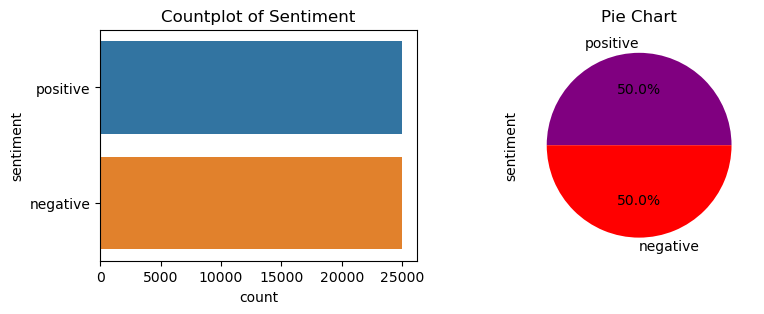

In [6]:
plt.figure(figsize =(9,3))
plt.subplot(121)
sns.countplot(y = 'sentiment' , data = df , hue = 'sentiment')
plt.title('Countplot of Sentiment')

plt.subplot(122)
sentiment_counts = df['sentiment'].value_counts()

plt.pie(x = sentiment_counts ,colors = ['purple','red'] , 
        labels = sentiment_counts.index , autopct='%1.1f%%' , startangle = 360)
plt.ylabel('sentiment')
plt.title('Pie Chart')

### Preprocessing review column

In [7]:
from nltk.stem import WordNetLemmatizer
import re

In [8]:
def preprocess(text):
    text = re.sub(r'[^a-zA-Z0-9]' , ' ' , text).split()

    text = [i.lower() for i in text]

    lemma = WordNetLemmatizer()
    text = [lemma.lemmatize(i , 'v') for i in text] 

    text = ' '.join(text)
    return text

In [9]:
df['review'] = df['review'].apply(preprocess)

### Some text after applying the function

In [10]:
for i in range(5):
    print(df['review'][i])
    print()

one of the other reviewers have mention that after watch just 1 oz episode you ll be hook they be right as this be exactly what happen with me br br the first thing that strike me about oz be its brutality and unflinching scenes of violence which set in right from the word go trust me this be not a show for the faint hearted or timid this show pull no punch with regard to drug sex or violence its be hardcore in the classic use of the word br br it be call oz as that be the nickname give to the oswald maximum security state penitentary it focus mainly on emerald city an experimental section of the prison where all the cells have glass front and face inwards so privacy be not high on the agenda em city be home to many aryans muslims gangstas latinos christians italians irish and more so scuffle death star dodgy dealings and shady agreements be never far away br br i would say the main appeal of the show be due to the fact that it go where other show wouldn t dare forget pretty picture pa

### Input (X) & Target (y) variable

In [11]:
X = df['review']
y = df['sentiment']

In [12]:
len(y)

50000

### One Hot encoding Target variables

In [13]:
from sklearn.preprocessing import LabelBinarizer
encoder = LabelBinarizer()
y = encoder.fit_transform(y)

In [15]:
pd.Series(y.ravel(), name='sentiment') #ravel() → flattens to 1D ,, squeeze() → removes dimensions of size 1

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

### Keras tokenizer object with 5000 max words
* Converting text to sequence
* Padding

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [17]:
tokenizer = Tokenizer(num_words = 5000)
tokenizer.fit_on_texts(X)

In [18]:
vocab_size = len(tokenizer.word_index) + 1

In [19]:
def text_encoding(text):
    encoded_docs = tokenizer.texts_to_sequences(text)
    padded_sequence = pad_sequences(encoded_docs , maxlen = 128)

    return padded_sequence

### Splitting into Training & Testing set

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.5)

In [23]:
X_train = text_encoding(X_train)
X_test = text_encoding(X_test)

### keras Sequential Model with LSTM Layers

In [24]:
from keras import layers , Sequential

In [25]:
model = Sequential()

model.add(layers.Embedding(input_dim = vocab_size , output_dim = 128 , input_shape = (128 , )))

model.add(layers.LSTM(128 , return_sequences = True))
model.add(layers.Dropout(0.2))

model.add(layers.LSTM(128))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(1 , activation  = 'sigmoid'))

C:\Users\Asharaf\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 128, 128)            │      11,327,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128, 128)            │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,599,105 (44.25 MB)

 Trainable params: 11,599,105 (44.25 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the model

In [27]:
model.compile(loss = 'binary_crossentropy' , optimizer = 'adam' , metrics = ['accuracy'])

### Training the model 

In [28]:
print(X_train.shape , y_train.shape )

(25000, 128) (25000, 1)


In [29]:
model.fit(X_train , y_train , epochs = 8  , validation_split = 0.2)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 231ms/step - accuracy: 0.7860 - loss: 0.4508 - val_accuracy: 0.8612 - val_loss: 0.3529
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.8774 - loss: 0.3015 - val_accuracy: 0.8700 - val_loss: 0.3260
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 234ms/step - accuracy: 0.9091 - loss: 0.2350 - val_accuracy: 0.8632 - val_loss: 0.3324
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 263ms/step - accuracy: 0.9270 - loss: 0.1901 - val_accuracy: 0.8440 - val_loss: 0.3527
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 267ms/step - accuracy: 0.9456 - loss: 0.1467 - val_accuracy: 0.8614 - val_loss: 0.4106
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 244ms/step - accuracy: 0.9613 - loss: 0.1131 - val_accuracy: 0.8546 - val_loss: 0.4147
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.9661 - loss: 0.1013 - val_accuracy: 0.8554 - val_loss: 0.4843
Epoch 8/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 249ms/step - accuracy: 0.9764 - loss: 0

### Predicting with X_test

In [30]:
y_pred = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step


### Converting to 0 and 1 with higher probability towards 1

In [31]:
y_pred = (y_pred >= 0.3).astype(int)

### Model Evaluation

In [32]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

#### Accuracy score

In [33]:
accuracy_score(y_test , y_pred)

0.84944

#### Confusion matrix

<Axes: >

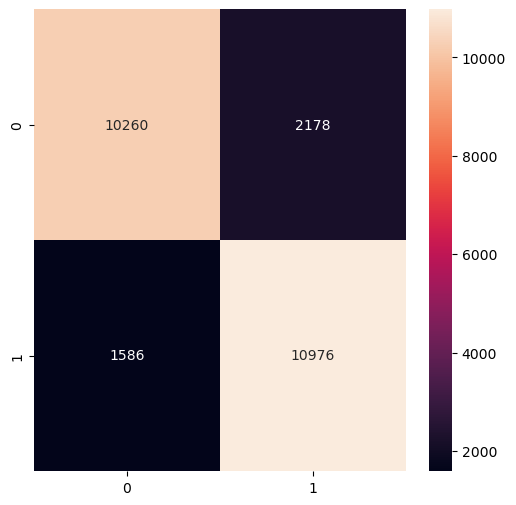

In [34]:
plt.figure(figsize = (6,6))
sns.heatmap(confusion_matrix(y_test,y_pred) , annot = True , fmt = 'd')

#### Classification report

In [35]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.85     12438
           1       0.83      0.87      0.85     12562

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



***